Name- Dheeraj Guleria
UID- GH1045036
Project : Rossman Sales Prediction
Project Report Link -
Github Link - 

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt


In [2]:
train = pd.read_csv("train.csv",low_memory=False)
store = pd.read_csv("store.csv")

data = train.merge(store, on="Store", how="left")


In [3]:
# Remove closed stores and zero sales
data = data[(data["Open"] == 1) & (data["Sales"] > 0)]

# Convert Date (explicit format – no warning)
data["Date"] = pd.to_datetime(data["Date"], format="%Y-%m-%d")

# Sort chronologically (VERY IMPORTANT)
data = data.sort_values("Date")


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [4]:
# Drop columns not used
data = data.drop(columns=["Customers", "Open"])

# One-hot encode categoricals
data = pd.get_dummies(
    data,
    columns=["StateHoliday", "StoreType", "Assortment", "PromoInterval"],
    drop_first=True
)

X = data.drop(columns=["Sales", "Date"])
y = data["Sales"]


In [6]:
N = len(X_scaled)

train_end = int(0.80 * N)
val_end   = int(0.90 * N)
test_end  = int(0.95 * N)

X_train = X_scaled[:train_end]
y_train = y.iloc[:train_end]

X_val = X_scaled[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X_scaled[val_end:test_end]
y_test = y.iloc[val_end:test_end]

X_holdout = X_scaled[test_end:]
y_holdout = y.iloc[test_end:]


In [7]:
from tensorflow.keras.layers import Input

baseline_model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation="relu"),
    Dense(1)
])

baseline_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)


In [8]:
baseline_history = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=256,
    verbose=1
)


Epoch 1/20
2639/2639 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 57489260.0000 - mae: 6913.8853 - val_loss: 58796624.0000 - val_mae: 7031.5376
Epoch 2/20
2639/2639 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 57452788.0000 - mae: 6911.2441 - val_loss: 58759568.0000 - val_mae: 7028.9038
Epoch 3/20
2639/2639 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 57416300.0000 - mae: 6908.6079 - val_loss: 58722484.0000 - val_mae: 7026.2632
Epoch 4/20
2639/2639 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 57379900.0000 - mae: 6905.9663 - val_loss: 58685388.0000 - val_mae: 7023.6289
Epoch 5/20
2639/2639 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 57343400.0000 - mae: 6903.3247 - val_loss: 58648396.0000 - val_mae: 7020.9917
Epoch 6/20
2639/2639 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 57307008.0000 - mae: 6900.6860 - val_loss: 58611380.0000 - val_mae: 7018.3579
Epoch 7/20
2639/2639 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 57270572.0000 - mae: 6898.0566 - val_loss: 58574360.0000 - val_mae: 7015.7217
Epoch 8/20
2639/2639

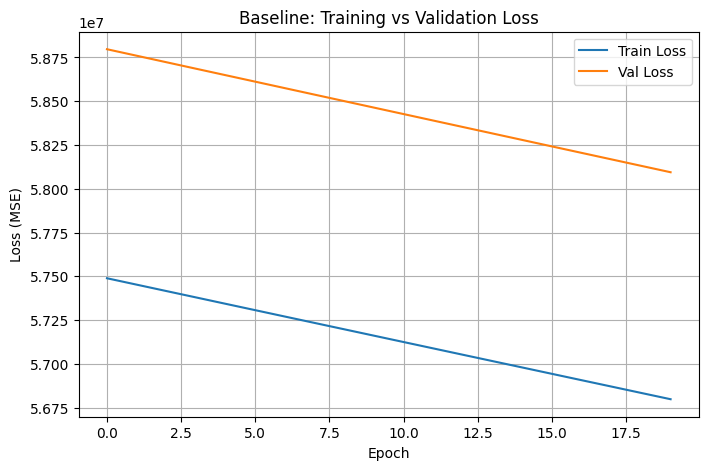

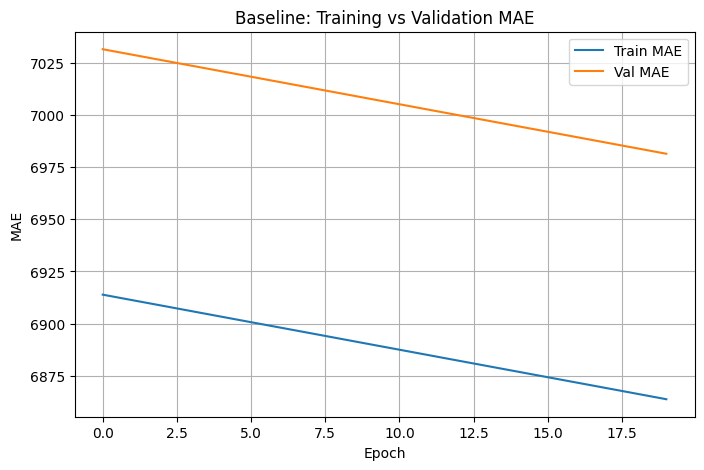

In [9]:
# Loss
plt.figure(figsize=(8,5))
plt.plot(baseline_history.history["loss"], label="Train Loss")
plt.plot(baseline_history.history["val_loss"], label="Val Loss")
plt.title("Baseline: Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.show()

# MAE
plt.figure(figsize=(8,5))
plt.plot(baseline_history.history["mae"], label="Train MAE")
plt.plot(baseline_history.history["val_mae"], label="Val MAE")
plt.title("Baseline: Training vs Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)
plt.show()


In [10]:
baseline_pred = baseline_model.predict(X_test)

baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_mae = mean_absolute_error(y_test, baseline_pred)

print("Baseline Test RMSE:", baseline_rmse)
print("Baseline Test MAE:", baseline_mae)


1320/1320 ━━━━━━━━━━━━━━━━━━━━ 1s 522us/step
Baseline Test RMSE: 7974.728083138634
Baseline Test MAE: 7354.32275390625


In [11]:
improved_model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(1)
])

improved_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)


C:\Users\dheer\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

improved_history = improved_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
2639/2639 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 54910944.0000 - mae: 6722.7349 - val_loss: 51524572.0000 - val_mae: 6493.8921
Epoch 2/50
2639/2639 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 43556408.0000 - mae: 5808.8672 - val_loss: 37202340.0000 - val_mae: 5279.7451
Epoch 3/50
2639/2639 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 29075178.0000 - mae: 4402.2319 - val_loss: 22688932.0000 - val_mae: 3722.7903
Epoch 4/50
2639/2639 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 17004486.0000 - mae: 2980.8616 - val_loss: 12755201.0000 - val_mae: 2480.0605
Epoch 5/50
2639/2639 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 11000862.0000 - mae: 2331.8547 - val_loss: 9547366.0000 - val_mae: 2217.5051
Epoch 6/50
2639/2639 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 10038576.0000 - mae: 2325.4915 - val_loss: 9382128.0000 - val_mae: 2241.6206
Epoch 7/50
2639/2639 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 10017080.0000 - mae: 2333.7771 - val_loss: 9383877.0000 - val_mae: 2240.9597
Epoch 8/50
2639/2639 ━

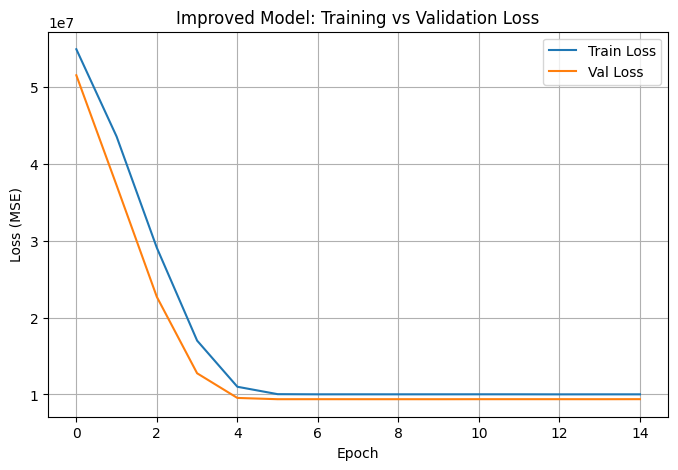

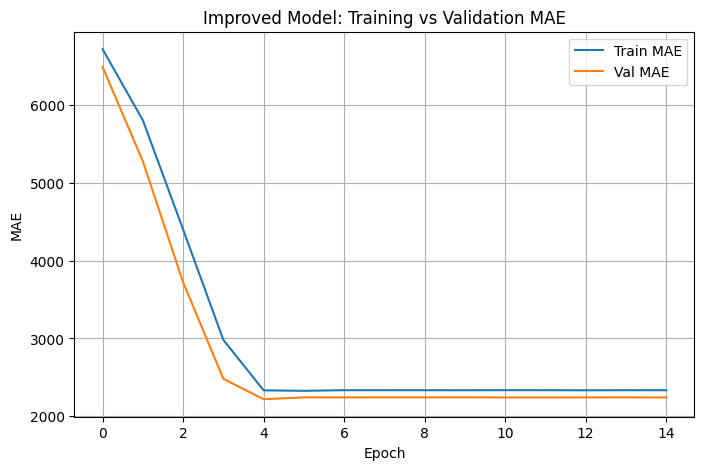

In [13]:
# LOSS
plt.figure(figsize=(8,5))
plt.plot(improved_history.history["loss"], label="Train Loss")
plt.plot(improved_history.history["val_loss"], label="Val Loss")
plt.title("Improved Model: Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.savefig("loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

# MAE
plt.figure(figsize=(8,5))
plt.plot(improved_history.history["mae"], label="Train MAE")
plt.plot(improved_history.history["val_mae"], label="Val MAE")
plt.title("Improved Model: Training vs Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)
plt.savefig("mae_curve.png", dpi=300, bbox_inches="tight")
plt.show()


In [14]:
improved_pred = improved_model.predict(X_test)

improved_rmse = np.sqrt(mean_squared_error(y_test, improved_pred))
improved_mae = mean_absolute_error(y_test, improved_pred)

print("Improved Test RMSE:", improved_rmse)
print("Improved Test MAE:", improved_mae)


1320/1320 ━━━━━━━━━━━━━━━━━━━━ 1s 572us/step
Improved Test RMSE: 3129.853510949035
Improved Test MAE: 2235.5078125


In [15]:
baseline_holdout_rmse = np.sqrt(
    mean_squared_error(y_holdout, baseline_model.predict(X_holdout))
)

improved_holdout_rmse = np.sqrt(
    mean_squared_error(y_holdout, improved_model.predict(X_holdout))
)

print("Baseline Hold-out RMSE:", baseline_holdout_rmse)
print("Improved Hold-out RMSE:", improved_holdout_rmse)


1320/1320 ━━━━━━━━━━━━━━━━━━━━ 1s 519us/step
1320/1320 ━━━━━━━━━━━━━━━━━━━━ 1s 572us/step
Baseline Hold-out RMSE: 7581.760217785841
Improved Hold-out RMSE: 3037.600862522922
